# Wycena historyczna opcji — LSM (Longstaff–Schwartz)

Notebook **backtestuje wycenę opcji z przeszłości** dla wielu spółek i porównuje ją z rzeczywistym wynikiem
przy wygaśnięciu. Kluczowa zasada: **zero look-ahead bias** — parametry modelu pochodzą
wyłącznie z informacji dostępnych w **dniu wyceny** $t_0$:

| Parametr | Źródło w $t_0$ |
|----------|----------------|
| $S_0$ | Cena zamknięcia akcji w $t_0$ |
| $\sigma$ | Zmienność historyczna z ostatnich 252 sesji **kończących się** w $t_0$ |
| $r$ | Stopa ^IRX (13T Treasury) w $t_0$ |
| $T$ | Czas do wygaśnięcia kontraktu (znany z kalendarza) |

**Spółki w analizie:** GOOG, AAPL, MSFT, NVDA, PLTR, JPM, RACE, GS, AMZN, GE

**Porównanie wycen:**
1. **LSM** — opcja amerykańska (Longstaff–Schwartz),
2. **Black–Scholes** — opcja europejska (benchmark),
3. **Wypłata zrealizowana** — rzeczywista wypłata przy wygaśnięciu $T$, zdyskontowana do $t_0$,
4. **Średnia różnica LSM − BS** — premia za wczesne wykonanie w danych historycznych.

> Yahoo Finance nie udostępnia historycznych kotowań opcji, dlatego jako „prawdę ex-post”
> stosujemy zrealizowaną wypłatę intrinsic przy wygaśnięciu.

In [20]:
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.stats import norm

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Styl pod tryb ciemny ---
DARK_BG = "#1a1a2e"
DARK_AXES = "#16213e"
DARK_GRID = "#3a3a5c"
DARK_TEXT = "#e8e8f0"
DARK_MUTED = "#9898b0"

COLORS = {
    "lsm": "#5dade2",       # jasny niebieski
    "bs": "#f5b041",        # jasny pomarańcz
    "realized": "#ec7063",  # koralowy
    "put": "#5dade2",
    "call": "#58d68d",      # zielony
    "spot": "#aeb6bf",
    "zero": "#7f8c8d",
    "error_pos": "#e74c3c",
    "error_neg": "#2ecc71",
}

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor": DARK_AXES,
    "axes.edgecolor": DARK_GRID,
    "axes.labelcolor": DARK_TEXT,
    "axes.titlecolor": "#ffffff",
    "axes.titleweight": "bold",
    "text.color": DARK_TEXT,
    "xtick.color": DARK_MUTED,
    "ytick.color": DARK_MUTED,
    "grid.color": DARK_GRID,
    "grid.alpha": 0.55,
    "legend.facecolor": DARK_AXES,
    "legend.edgecolor": DARK_GRID,
    "legend.labelcolor": DARK_TEXT,
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def _style_ax(ax):
    ax.grid(True, linestyle="--", alpha=0.45)
    ax.tick_params(colors=DARK_MUTED)
    for spine in ax.spines.values():
        spine.set_color(DARK_GRID)


TICKERS = ["GOOG", "AAPL", "MSFT", "NVDA", "PLTR", "JPM", "RACE", "GS", "AMZN", "GE"]
TICKER = "GOOG"  # główny ticker do szczegółowej wizualizacji
RNG_SEED = 42
VOL_LOOKBACK = 252   # dni handlowe do estymacji σ
M_STEPS = 126
N_PATHS = 20_000
LATA_HISTORII = 3

## 1. Dane historyczne i scenariusze backtestu

In [21]:
def _normalize_index(df: pd.DataFrame) -> pd.DataFrame:
    """Usuwa strefę czasową z indeksu dat."""
    out = df.copy()
    if isinstance(out.index, pd.DatetimeIndex) and out.index.tz is not None:
        out.index = out.index.tz_localize(None)
    return out.sort_index()


def pobierz_spot(ticker: str, lata: int = LATA_HISTORII) -> pd.DataFrame:
    """Pobiera historię cen akcji."""
    start = (datetime.now().replace(year=datetime.now().year - lata)).strftime("%Y-%m-%d")
    spot = _normalize_index(yf.Ticker(ticker).history(start=start))
    if spot.empty:
        raise RuntimeError(f"Brak historii dla {ticker}")
    return spot


def pobierz_irx(lata: int = LATA_HISTORII) -> pd.DataFrame:
    """Pobiera historię stopy ^IRX (wspólna dla wszystkich spółek)."""
    start = (datetime.now().replace(year=datetime.now().year - lata)).strftime("%Y-%m-%d")
    return _normalize_index(yf.Ticker("^IRX").history(start=start))


def sigma_w_dniu(spot: pd.DataFrame, data_wyceny: pd.Timestamp, lookback: int = VOL_LOOKBACK) -> float:
    """Roczna σ z log-zwrotów — tylko dane do daty wyceny włącznie."""
    closes = spot.loc[:data_wyceny, "Close"].dropna()
    if len(closes) < 22:
        return np.nan
    window = closes.tail(lookback)
    log_rets = np.log(window / window.shift(1)).dropna()
    return float(log_rets.std() * np.sqrt(252))


def r_w_dniu(irx: pd.DataFrame, data_wyceny: pd.Timestamp, fallback: float = 0.04) -> float:
    """Stopa wolna od ryzyka w dniu wyceny (^IRX / 100)."""
    series = irx.loc[:data_wyceny, "Close"].dropna()
    if series.empty:
        return fallback
    return float(series.iloc[-1] / 100.0)


def S_w_dniu(spot: pd.DataFrame, data: pd.Timestamp) -> float:
    return float(spot.loc[:data, "Close"].iloc[-1])


def generuj_scenariusze(
    spot: pd.DataFrame,
    co_ile_sesji: int = 21,
    dni_do_exp_min: int = 18,
    dni_do_exp_max: int = 35,
) -> list[tuple[pd.Timestamp, pd.Timestamp]]:
    """
    Tworzy pary (data_wyceny, data_wygasniecia) z przeszłości.
    Wygaśnięcie = ~25 sesji po dacie wyceny (musi być w przeszłości).
    """
    dates = spot.index
    today = pd.Timestamp(datetime.now().date())
    scenariusze = []

    i = VOL_LOOKBACK
    while i + dni_do_exp_min < len(dates):
        data_wyceny = dates[i]
        exp_idx = i + (dni_do_exp_min + dni_do_exp_max) // 2
        if exp_idx >= len(dates):
            break
        data_exp = dates[exp_idx]
        dni = (data_exp - data_wyceny).days
        if dni_do_exp_min <= dni <= dni_do_exp_max + 5 and data_exp < today:
            scenariusze.append((data_wyceny, data_exp))
        i += co_ile_sesji

    return scenariusze


irx_hist = pobierz_irx()
spot_cache: dict[str, pd.DataFrame] = {}

for t in TICKERS:
    try:
        spot_cache[t] = pobierz_spot(t)
        print(f"{t:5s}: {spot_cache[t].index[0].date()} → {spot_cache[t].index[-1].date()}  ({len(spot_cache[t])} sesji)")
    except Exception as exc:
        print(f"{t:5s}: BŁĄD — {exc}")

spot_hist = spot_cache[TICKER]
scenariusze = generuj_scenariusze(spot_hist)
print(f"\n{TICKER}: {len(scenariusze)} scenariuszy backtestu  ({scenariusze[0][0].date()} → {scenariusze[-1][0].date()})")

GOOG : 2023-05-25 → 2026-05-22  (751 sesji)
AAPL : 2023-05-25 → 2026-05-22  (751 sesji)
MSFT : 2023-05-25 → 2026-05-22  (751 sesji)
NVDA : 2023-05-25 → 2026-05-22  (751 sesji)
PLTR : 2023-05-25 → 2026-05-22  (751 sesji)
JPM  : 2023-05-25 → 2026-05-22  (751 sesji)
RACE : 2023-05-25 → 2026-05-22  (751 sesji)
GS   : 2023-05-25 → 2026-05-22  (751 sesji)
AMZN : 2023-05-25 → 2026-05-22  (751 sesji)
GE   : 2023-05-25 → 2026-05-22  (751 sesji)

GOOG: 22 scenariuszy backtestu  (2024-05-28 → 2026-04-01)


## 2. Modele wyceny

In [22]:
def bs_european(S0: float, K: float, r: float, sigma: float, T: float, typ: str = "put") -> float:
    if T <= 0 or sigma <= 0:
        return max(K - S0, 0.0) if typ == "put" else max(S0 - K, 0.0)
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if typ == "call":
        return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)


def symuluj_sciezki_gbm(S0, r, sigma, T, M, N, seed=RNG_SEED):
    dt = T / M
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal((N, M))
    log_increments = (r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.log(S0) + np.cumsum(log_increments, axis=1)
    return np.exp(np.concatenate([np.full((N, 1), np.log(S0)), log_paths], axis=1))


def lsm_longstaff_schwartz(
    S0, K, r, sigma, T, typ="put", M=M_STEPS, N=N_PATHS, seed=RNG_SEED,
):
    dt = T / M
    disc = np.exp(-r * dt)
    S = symuluj_sciezki_gbm(S0, r, sigma, T, M, N, seed)
    H = np.maximum(K - S, 0.0) if typ == "put" else np.maximum(S - K, 0.0)

    cashflow = H[:, -1].copy()
    exercise_time = np.full(N, M, dtype=int)

    for t in range(M - 1, 0, -1):
        itm = H[:, t] > 0
        if not np.any(itm):
            continue
        discount = disc ** (exercise_time - t)
        continuation = cashflow * discount
        X = S[itm, t]
        Y = continuation[itm]
        if len(X) < 10:
            continue
        A = np.column_stack([np.ones_like(X), X, X ** 2])
        beta, _, _, _ = np.linalg.lstsq(A, Y, rcond=1e-8)
        predicted = np.clip(A @ beta, 0.0, None)
        exercise_now = H[itm, t] > predicted
        for j, idx in enumerate(np.where(itm)[0]):
            if exercise_now[j]:
                cashflow[idx] = H[idx, t]
                exercise_time[idx] = t

    pv = cashflow * (disc ** exercise_time)
    return float(pv.mean()), float(pv.std(ddof=1) / np.sqrt(N))


def wypłata_zrealizowana(S_T: float, K: float, typ: str) -> float:
    return max(K - S_T, 0.0) if typ == "put" else max(S_T - K, 0.0)


def krok_strike(S0: float) -> float:
    """Dobiera krok strike w zależności od ceny akcji."""
    if S0 < 25:
        return 1.0
    if S0 < 100:
        return 2.5
    return 5.0


def atm_strike(S0: float) -> float:
    step = krok_strike(S0)
    return round(S0 / step) * step

## 3. Backtest — wycena ex-ante vs wynik ex-post

In [23]:
def uruchom_backtest(
    ticker: str,
    spot: pd.DataFrame,
    irx: pd.DataFrame,
    scenariusze: list,
    typy: list[str] = ("put", "call"),
    strikes_wzgl: list[float] = (0.0,),
) -> pd.DataFrame:
    """
    Dla każdego scenariusza wycenia opcję w t₀ (tylko dane do t₀)
    i porównuje z zrealizowaną wypłatą przy wygaśnięciu.
    """
    rows = []
    for idx, (t0, t_exp) in enumerate(scenariusze):
        S0 = S_w_dniu(spot, t0)
        S_T = S_w_dniu(spot, t_exp)
        sigma = sigma_w_dniu(spot, t0)
        r = r_w_dniu(irx, t0)
        T = max((t_exp - t0).days / 365.0, 1 / 365)

        if np.isnan(sigma) or sigma <= 0:
            continue

        step = krok_strike(S0)
        for offset in strikes_wzgl:
            K = atm_strike(S0 * (1 + offset))
            K = round(K / step) * step

            for typ in typy:
                seed = RNG_SEED + hash(ticker) % 10_000 + idx * 10 + int(offset * 100)
                lsm, lsm_se = lsm_longstaff_schwartz(
                    S0, K, r, sigma, T, typ=typ, seed=seed
                )
                bs = bs_european(S0, K, r, sigma, T, typ=typ)
                payoff = wypłata_zrealizowana(S_T, K, typ)
                payoff_pv = np.exp(-r * T) * payoff

                rows.append({
                    "ticker": ticker,
                    "data_wyceny": t0.date(),
                    "data_wygasniecia": t_exp.date(),
                    "T_lat": T,
                    "typ": typ.upper(),
                    "S0": S0,
                    "S_T": S_T,
                    "K": K,
                    "sigma": sigma,
                    "r": r,
                    "lsm": lsm,
                    "lsm_se": lsm_se,
                    "bs": bs,
                    "lsm_minus_bs": lsm - bs,
                    "premia_amerykanska": lsm - bs,
                    "wypłata_rzeczywista": payoff,
                    "wypłata_zdyskontowana": payoff_pv,
                    "blad_lsm": lsm - payoff_pv,
                    "blad_bs": bs - payoff_pv,
                })

    return pd.DataFrame(rows)


def backtest_wszystkie_tickery(
    tickers: list[str],
    spot_cache: dict[str, pd.DataFrame],
    irx: pd.DataFrame,
) -> pd.DataFrame:
    """Uruchamia backtest dla każdego tickera i łączy wyniki."""
    ramki = []
    for ticker in tickers:
        if ticker not in spot_cache:
            print(f"  {ticker}: pominięty (brak danych)")
            continue
        spot = spot_cache[ticker]
        scen = generuj_scenariusze(spot)
        if not scen:
            print(f"  {ticker}: pominięty (brak scenariuszy)")
            continue
        print(f"  {ticker}: {len(scen)} scenariuszy × 2 typy opcji...")
        df = uruchom_backtest(ticker, spot, irx, scen)
        ramki.append(df)
        print(f"           → {len(df)} wierszy")
    return pd.concat(ramki, ignore_index=True) if ramki else pd.DataFrame()


print("Uruchamianie backtestu dla wszystkich spółek...")
wyniki_all = backtest_wszystkie_tickery(TICKERS, spot_cache, irx_hist)
wyniki = wyniki_all[wyniki_all["ticker"] == TICKER].copy()
print(f"\nRazem: {len(wyniki_all)} wierszy  |  {TICKER}: {len(wyniki)} wierszy")
wyniki_all.head()

Uruchamianie backtestu dla wszystkich spółek...
  GOOG: 22 scenariuszy × 2 typy opcji...


/var/folders/f5/4k5qrc256832lvh3kr6862w00000gn/T/ipykernel_6099/2215402750.py:43: RuntimeWarning: divide by zero encountered in matmul
  predicted = np.clip(A @ beta, 0.0, None)
/var/folders/f5/4k5qrc256832lvh3kr6862w00000gn/T/ipykernel_6099/2215402750.py:43: RuntimeWarning: overflow encountered in matmul
  predicted = np.clip(A @ beta, 0.0, None)
/var/folders/f5/4k5qrc256832lvh3kr6862w00000gn/T/ipykernel_6099/2215402750.py:43: RuntimeWarning: invalid value encountered in matmul
  predicted = np.clip(A @ beta, 0.0, None)


           → 44 wierszy
  AAPL: 22 scenariuszy × 2 typy opcji...
           → 44 wierszy
  MSFT: 22 scenariuszy × 2 typy opcji...
           → 44 wierszy
  NVDA: 22 scenariuszy × 2 typy opcji...
           → 44 wierszy
  PLTR: 22 scenariuszy × 2 typy opcji...
           → 44 wierszy
  JPM: 22 scenariuszy × 2 typy opcji...
           → 44 wierszy
  RACE: 22 scenariuszy × 2 typy opcji...
           → 44 wierszy
  GS: 22 scenariuszy × 2 typy opcji...
           → 44 wierszy
  AMZN: 22 scenariuszy × 2 typy opcji...
           → 44 wierszy
  GE: 22 scenariuszy × 2 typy opcji...
           → 44 wierszy

Razem: 440 wierszy  |  GOOG: 44 wierszy


,ticker,data_wyceny,data_wygasniecia,T_lat,typ,S0,S_T,K,sigma,r,lsm,lsm_se,bs,lsm_minus_bs,premia_amerykanska,wypłata_rzeczywista,wypłata_zdyskontowana,blad_lsm,blad_bs
0,GOOG,2024-05-28,2024-07-05,0.104110,PUT,176.570358,190.613541,175.0,0.280253,0.05248,5.281169,0.047645,5.140041,0.141128,0.141128,0.000000,0.000000,5.281169,5.140041
1,GOOG,2024-05-28,2024-07-05,0.104110,CALL,176.570358,190.613541,175.0,0.280253,0.05248,7.363465,0.063550,7.663934,-0.300469,-0.300469,15.613541,15.528466,-8.165001,-7.864532
2,GOOG,2024-06-27,2024-08-05,0.106849,PUT,185.549286,159.513199,185.0,0.275666,0.05223,5.971334,0.051620,5.879952,0.091382,0.091382,25.486801,25.344962,-19.373628,-19.465010
3,GOOG,2024-06-27,2024-08-05,0.106849,CALL,185.549286,159.513199,185.0,0.275666,0.05223,7.280460,0.065298,7.458799,-0.178339,-0.178339,0.000000,0.000000,7.280460,7.458799
4,GOOG,2024-07-29,2024-09-04,0.101370,PUT,169.929626,156.703064,170.0,0.274570,0.05147,5.556131,0.045516,5.512034,0.044096,0.044096,13.296936,13.227740,-7.671609,-7.715705


In [24]:
fmt = [
    "ticker", "data_wyceny", "data_wygasniecia", "typ", "S0", "S_T", "K",
    "lsm", "bs", "lsm_minus_bs", "wypłata_zdyskontowana", "blad_lsm", "blad_bs",
]

print("=" * 100)
print(f"BACKTEST {TICKER} — wycena ex-ante vs wypłata ex-post")
print("=" * 100)
print(wyniki[fmt].tail(8).to_string(index=False, float_format=lambda x: f"{x:9.4f}"))

print("\n--- Metryki jakości wyceny GOOG (vs zdyskontowana wypłata) ---")
for typ in ["PUT", "CALL"]:
    sub = wyniki[wyniki["typ"] == typ]
    if sub.empty:
        continue
    for metoda, col in [("LSM", "blad_lsm"), ("BS", "blad_bs")]:
        err = sub[col]
        print(
            f"{typ:4s} {metoda:3s}: MAE={err.abs().mean():7.4f}  "
            f"RMSE={np.sqrt((err**2).mean()):7.4f}  bias={err.mean():+7.4f}"
        )

BACKTEST GOOG — wycena ex-ante vs wypłata ex-post
ticker data_wyceny data_wygasniecia  typ        S0       S_T         K       lsm        bs  lsm_minus_bs  wypłata_zdyskontowana  blad_lsm   blad_bs
  GOOG  2025-12-30       2026-02-06  PUT  314.3286  322.8726  315.0000   12.6265   12.5856        0.0409                 0.0000   12.6265   12.5856
  GOOG  2025-12-30       2026-02-06 CALL  314.3286  322.8726  315.0000   12.8873   13.0729       -0.1856                 7.8436    5.0437    5.2293
  GOOG  2026-01-30       2026-03-10  PUT  338.2917  306.9300  340.0000   13.9281   14.0085       -0.0804                32.9440  -19.0159  -18.9355
  GOOG  2026-01-30       2026-03-10 CALL  338.2917  306.9300  340.0000   13.5825   13.5954       -0.0129                 0.0000   13.5825   13.5954
  GOOG  2026-03-03       2026-04-09  PUT  303.3463  316.3700  305.0000   11.7167   11.9849       -0.2682                 0.0000   11.7167   11.9849
  GOOG  2026-03-03       2026-04-09 CALL  303.3463  316.3700  

## 4. Porównanie wielospółkowe — średnia różnica LSM − BS

Premia amerykańska = **LSM − BS** (w USD). Dla call-i bez dywidendy teoretycznie ≈ 0;
dla put-ów ITM/ATM powinna być dodatnia (wczesne wykonanie ma wartość).

In [25]:
def podsumowanie_lsm_bs(df: pd.DataFrame) -> pd.DataFrame:
    """Średnia różnica LSM − BS per ticker i typ opcji."""
    grp = df.groupby(["ticker", "typ"]).agg(
        srednia_lsm_minus_bs=("lsm_minus_bs", "mean"),
        mediana_lsm_minus_bs=("lsm_minus_bs", "median"),
        std_lsm_minus_bs=("lsm_minus_bs", "std"),
        srednia_lsm=("lsm", "mean"),
        srednia_bs=("bs", "mean"),
        n_obs=("lsm_minus_bs", "count"),
    ).reset_index()
    return grp.sort_values(["typ", "ticker"])


podsumowanie = podsumowanie_lsm_bs(wyniki_all)

print("=" * 90)
print("ŚREDNIA RÓŻNICA LSM − BS (premia za wczesne wykonanie) — dane historyczne")
print("=" * 90)
print(podsumowanie.to_string(index=False, float_format=lambda x: f"{x:10.4f}"))

print("\n--- Średnia globalna (wszystkie spółki) ---")
for typ in ["PUT", "CALL"]:
    sub = wyniki_all[wyniki_all["typ"] == typ]["lsm_minus_bs"]
    print(
        f"{typ:4s}: średnia LSM−BS = {sub.mean():+.4f} USD  "
        f"(mediana {sub.median():+.4f}, n={len(sub)})"
    )

print("\n--- Średnia LSM−BS per spółka (PUT + CALL) ---")
per_ticker = (
    wyniki_all.groupby("ticker")["lsm_minus_bs"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "srednia_lsm_minus_bs", "count": "n"})
    .sort_values("srednia_lsm_minus_bs", ascending=False)
)
print(per_ticker.to_string(float_format=lambda x: f"{x:10.4f}"))

srednia_globalna = wyniki_all["lsm_minus_bs"].mean()
print(f"\n>>> ŚREDNIA GLOBALNA LSM − BS (wszystkie spółki, PUT+CALL): {srednia_globalna:+.4f} USD")
podsumowanie

ŚREDNIA RÓŻNICA LSM − BS (premia za wczesne wykonanie) — dane historyczne
ticker  typ  srednia_lsm_minus_bs  mediana_lsm_minus_bs  std_lsm_minus_bs  srednia_lsm  srednia_bs  n_obs
  AAPL CALL               -0.0967               -0.0919            0.0924       8.8843      8.9810     22
  AMZN CALL               -0.0887               -0.0887            0.0757       8.7165      8.8052     22
    GE CALL               -0.1177               -0.1262            0.0820       9.4250      9.5427     22
  GOOG CALL               -0.0959               -0.0657            0.1278       8.6613      8.7572     22
    GS CALL               -0.4415               -0.3386            0.2302      25.8556     26.2971     22
   JPM CALL               -0.0962               -0.1002            0.0868       8.6290      8.7252     22
  MSFT CALL               -0.2029               -0.1914            0.1398      13.7241     13.9270     22
  NVDA CALL               -0.0105               -0.0197            0.0769     

,ticker,typ,srednia_lsm_minus_bs,mediana_lsm_minus_bs,std_lsm_minus_bs,srednia_lsm,srednia_bs,n_obs
0,AAPL,CALL,-0.096738,-0.091909,0.092412,8.884276,8.981014,22
2,AMZN,CALL,-0.088679,-0.088734,0.075737,8.716526,8.805205,22
4,GE,CALL,-0.117737,-0.126151,0.082021,9.424957,9.542695,22
6,GOOG,CALL,-0.095893,-0.065688,0.127828,8.661301,8.757194,22
8,GS,CALL,-0.441512,-0.338647,0.230185,25.855609,26.297121,22
10,JPM,CALL,-0.096160,-0.100205,0.086822,8.629038,8.725198,22
12,MSFT,CALL,-0.202878,-0.191360,0.139847,13.724133,13.927011,22
14,NVDA,CALL,-0.010540,-0.019728,0.076854,9.900201,9.910741,22
16,PLTR,CALL,-0.085599,-0.032023,0.123205,9.443990,9.529588,22
18,RACE,CALL,-0.207408,-0.202658,0.165661,16.645225,16.852634,22


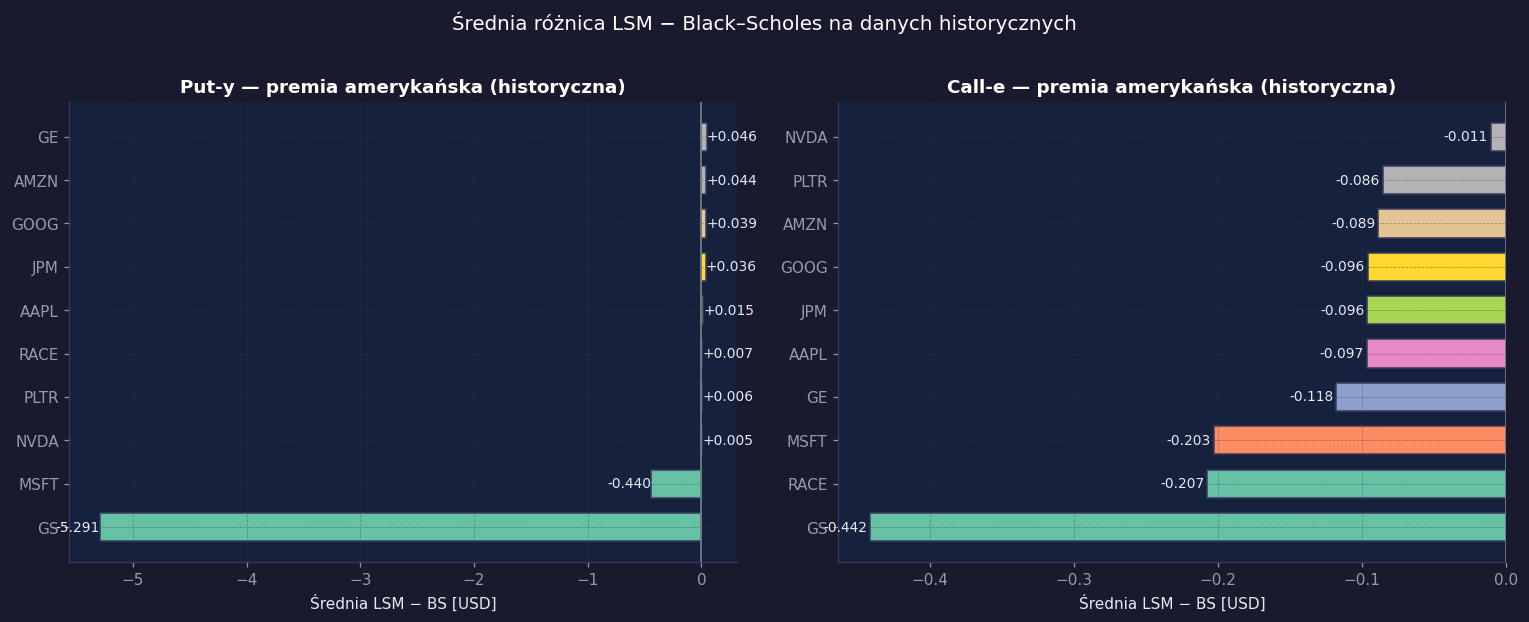

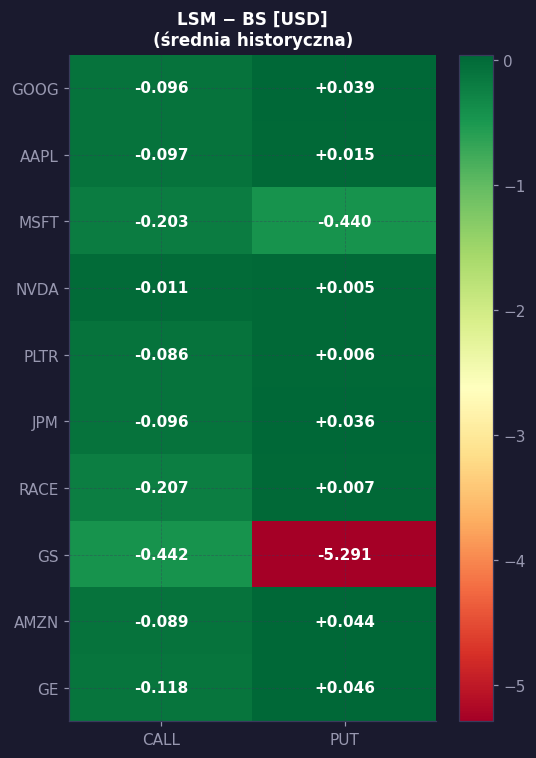

In [26]:
# Wykres: średnia LSM − BS per spółka (tryb ciemny)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

palette = plt.cm.Set2(np.linspace(0, 1, len(TICKERS)))

for ax, typ, title in zip(axes, ["PUT", "CALL"], ["Put-y", "Call-e"]):
    sub = podsumowanie[podsumowanie["typ"] == typ].sort_values("srednia_lsm_minus_bs", ascending=True)
    y_pos = np.arange(len(sub))
    bars = ax.barh(y_pos, sub["srednia_lsm_minus_bs"], color=palette[: len(sub)], edgecolor=DARK_GRID, height=0.65)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub["ticker"])
    ax.axvline(0, color=COLORS["zero"], lw=1)
    ax.set_xlabel("Średnia LSM − BS [USD]")
    ax.set_title(f"{title} — premia amerykańska (historyczna)")
    for bar, val in zip(bars, sub["srednia_lsm_minus_bs"]):
        ax.text(
            val + (0.002 if val >= 0 else -0.002), bar.get_y() + bar.get_height() / 2,
            f"{val:+.3f}", va="center", ha="left" if val >= 0 else "right",
            color=DARK_TEXT, fontsize=9,
        )
    _style_ax(ax)

fig.suptitle("Średnia różnica LSM − Black–Scholes na danych historycznych", color="#ffffff", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Heatmapa: ticker × typ
pivot = podsumowanie.pivot(index="ticker", columns="typ", values="srednia_lsm_minus_bs")
pivot = pivot.reindex(TICKERS).dropna(how="all")

fig, ax = plt.subplots(figsize=(5, 7))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:+.3f}", ha="center", va="center", color="#ffffff", fontsize=10, fontweight="bold")
ax.set_title("LSM − BS [USD]\n(średnia historyczna)", fontsize=11)
cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=DARK_MUTED)
cbar.outline.set_edgecolor(DARK_GRID)
plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color=DARK_MUTED)
_style_ax(ax)
plt.tight_layout()
plt.show()

## 5. Wizualizacja GOOG (tryb ciemny)

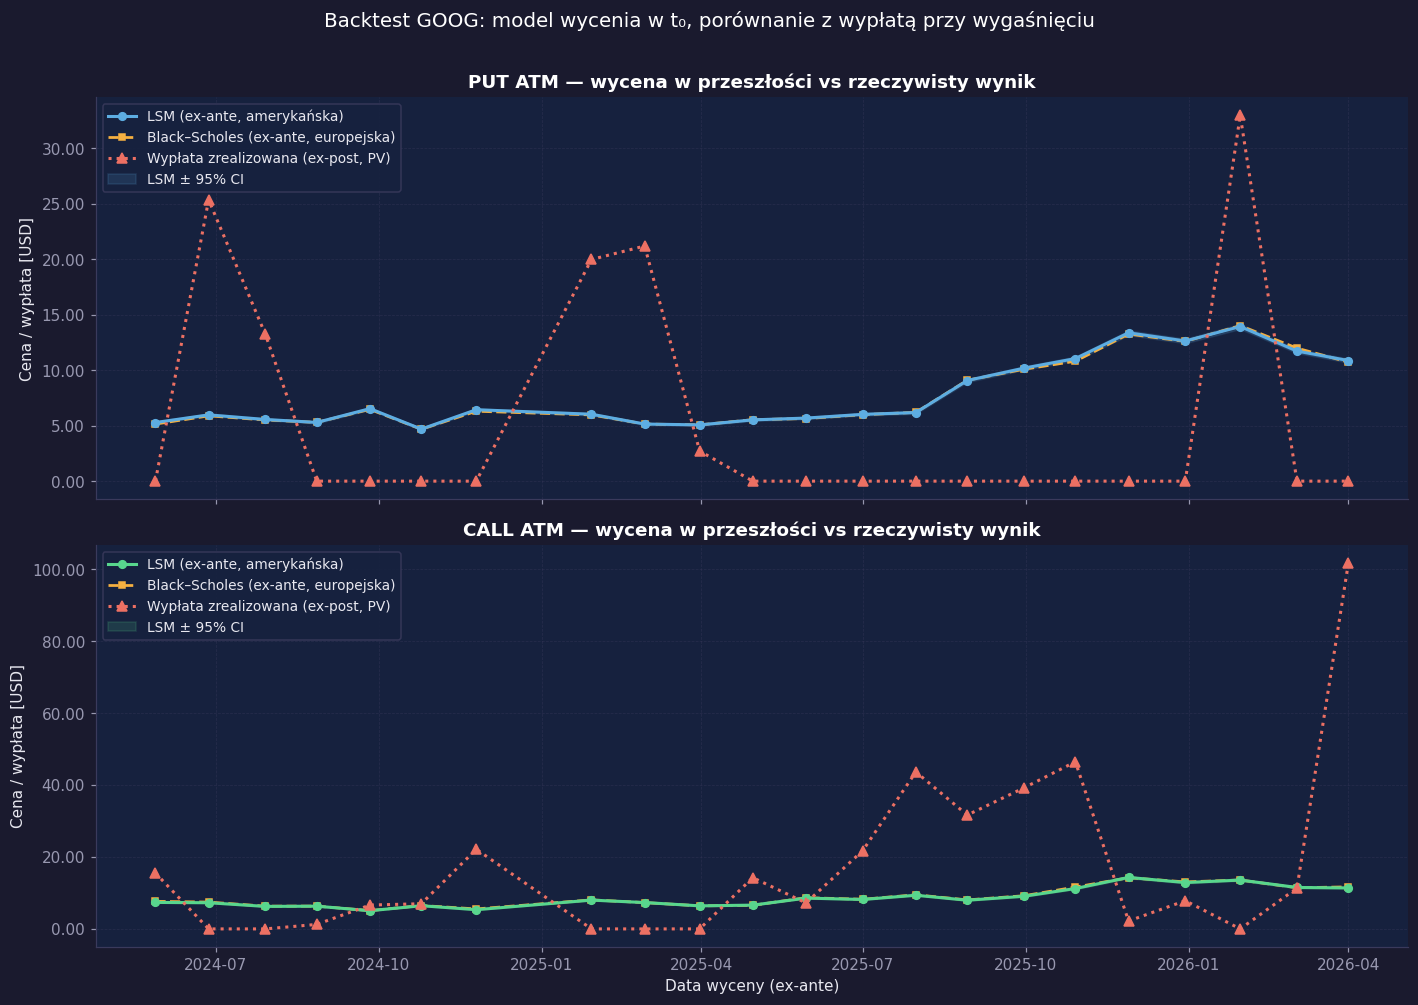

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

for ax, typ, color_lsm, color_bs in zip(
    axes,
    ["PUT", "CALL"],
    [COLORS["put"], COLORS["call"]],
    [COLORS["bs"], COLORS["bs"]],
):
    sub = wyniki[wyniki["typ"] == typ].sort_values("data_wyceny")
    x = pd.to_datetime(sub["data_wyceny"])

    ax.plot(x, sub["lsm"], "o-", color=color_lsm, lw=2, ms=5,
            label="LSM (ex-ante, amerykańska)", zorder=3)
    ax.plot(x, sub["bs"], "s--", color=color_bs, lw=1.8, ms=4,
            label="Black–Scholes (ex-ante, europejska)", zorder=2)
    ax.plot(x, sub["wypłata_zdyskontowana"], "^:", color=COLORS["realized"], lw=2, ms=6,
            label="Wypłata zrealizowana (ex-post, PV)", zorder=4)

    ax.fill_between(x, sub["lsm"] - 1.96 * sub["lsm_se"], sub["lsm"] + 1.96 * sub["lsm_se"],
                    color=color_lsm, alpha=0.15, label="LSM ± 95% CI")
    ax.set_ylabel("Cena / wypłata [USD]")
    ax.set_title(f"{typ} ATM — wycena w przeszłości vs rzeczywisty wynik")
    ax.legend(loc="upper left", fontsize=9, framealpha=0.85)
    _style_ax(ax)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

axes[-1].set_xlabel("Data wyceny (ex-ante)")
fig.suptitle(
    f"Backtest {TICKER}: model wycenia w t₀, porównanie z wypłatą przy wygaśnięciu",
    fontsize=13, color="#ffffff", y=1.01,
)
plt.tight_layout()
plt.show()

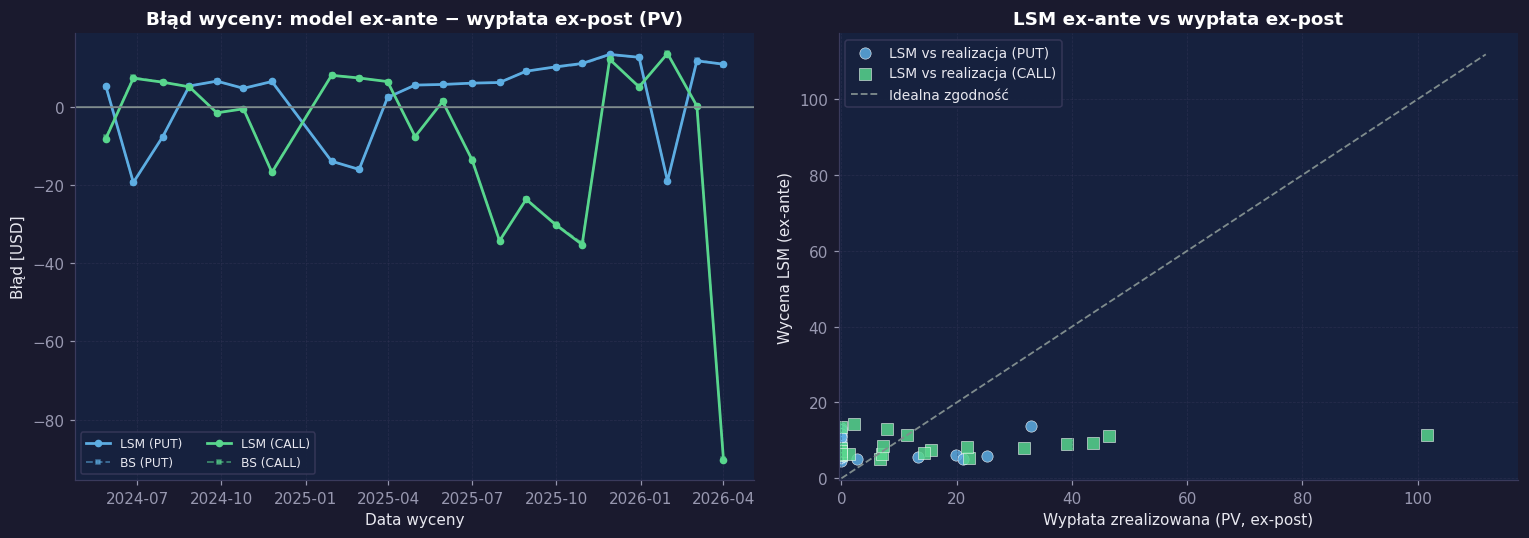

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: błąd wyceny w czasie
for typ, color in [("PUT", COLORS["put"]), ("CALL", COLORS["call"])]:
    sub = wyniki[wyniki["typ"] == typ].sort_values("data_wyceny")
    x = pd.to_datetime(sub["data_wyceny"])
    axes[0].plot(x, sub["blad_lsm"], "o-", color=color, lw=1.8, ms=4, label=f"LSM ({typ})")
    axes[0].plot(x, sub["blad_bs"], "s--", color=color, lw=1.2, ms=3, alpha=0.55, label=f"BS ({typ})")

axes[0].axhline(0, color=COLORS["zero"], lw=1)
axes[0].set_title("Błąd wyceny: model ex-ante − wypłata ex-post (PV)")
axes[0].set_xlabel("Data wyceny")
axes[0].set_ylabel("Błąd [USD]")
axes[0].legend(fontsize=8, ncol=2, framealpha=0.85)
axes[0].axhline(0, color=COLORS["zero"], lw=0.8)
_style_ax(axes[0])

# Wykres 2: scatter LSM vs wypłata
for typ, color, marker in [("PUT", COLORS["put"], "o"), ("CALL", COLORS["call"], "s")]:
    sub = wyniki[wyniki["typ"] == typ]
    axes[1].scatter(
        sub["wypłata_zdyskontowana"], sub["lsm"],
        c=color, s=55, alpha=0.85, marker=marker, edgecolors="#ffffff", linewidths=0.4,
        label=f"LSM vs realizacja ({typ})",
    )

lim_max = max(wyniki["wypłata_zdyskontowana"].max(), wyniki["lsm"].max()) * 1.1
axes[1].plot([0, lim_max], [0, lim_max], "--", color=COLORS["zero"], lw=1.2, label="Idealna zgodność")
axes[1].set_xlabel("Wypłata zrealizowana (PV, ex-post)")
axes[1].set_ylabel("Wycena LSM (ex-ante)")
axes[1].set_title("LSM ex-ante vs wypłata ex-post")
axes[1].legend(fontsize=9, framealpha=0.85)
axes[1].set_xlim(left=-0.5)
axes[1].set_ylim(bottom=-0.5)
_style_ax(axes[1])

plt.tight_layout()
plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\%'
<>:17: SyntaxWarning: invalid escape sequence '\%'
/var/folders/f5/4k5qrc256832lvh3kr6862w00000gn/T/ipykernel_6099/1147737269.py:17: SyntaxWarning: invalid escape sequence '\%'
  axes[2].set_ylabel("$r$ [\% rocznie]")


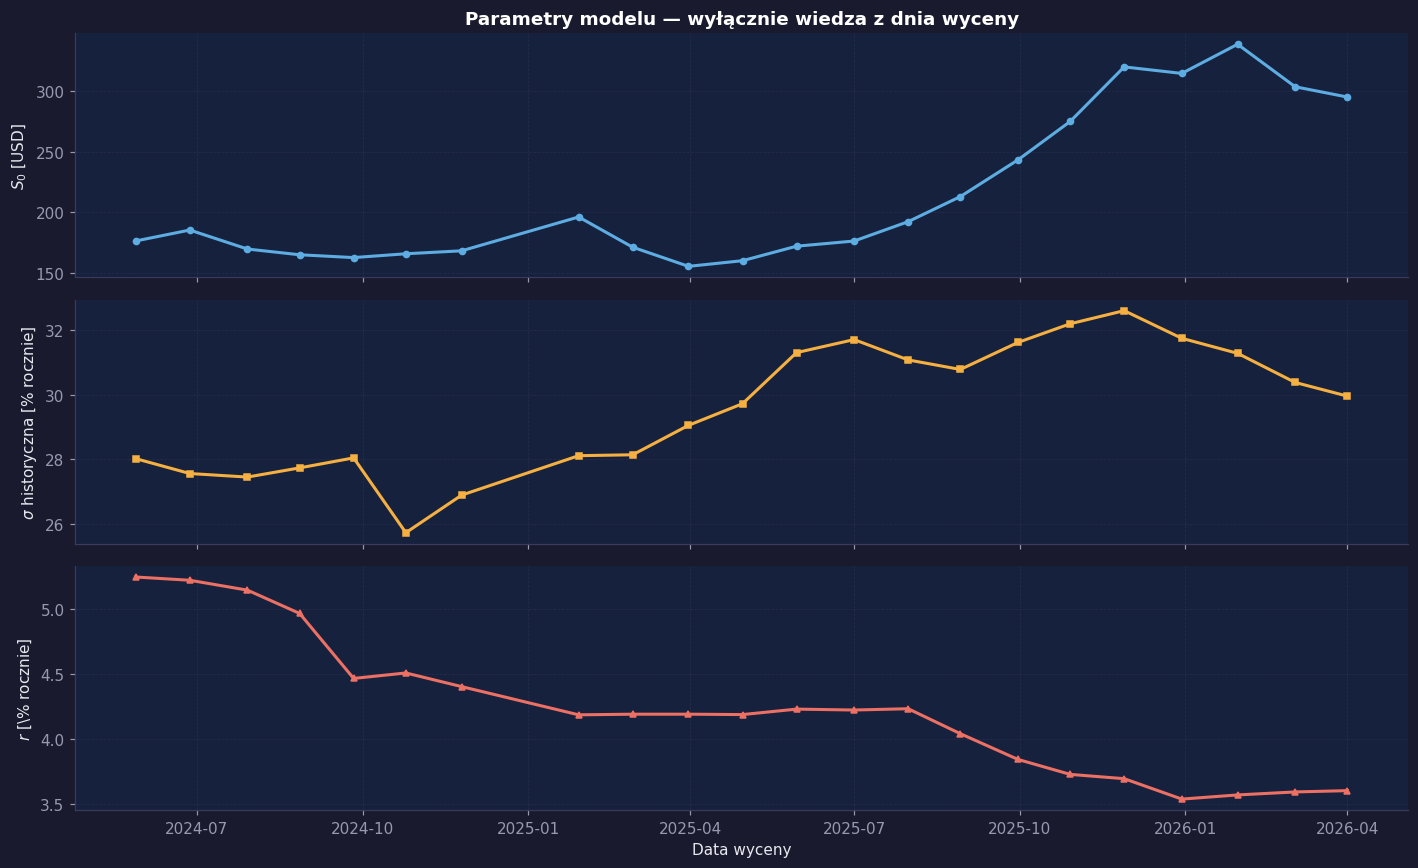

In [29]:
# Wykres parametrów ex-ante w czasie (weryfikacja braku look-ahead)
sub = wyniki[wyniki["typ"] == "PUT"].drop_duplicates("data_wyceny").sort_values("data_wyceny")
x = pd.to_datetime(sub["data_wyceny"])

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

axes[0].plot(x, sub["S0"], color=COLORS["lsm"], lw=2, marker="o", ms=4)
axes[0].set_ylabel("$S_0$ [USD]")
axes[0].set_title("Parametry modelu — wyłącznie wiedza z dnia wyceny")
_style_ax(axes[0])

axes[1].plot(x, sub["sigma"] * 100, color=COLORS["bs"], lw=2, marker="s", ms=4)
axes[1].set_ylabel("$\\sigma$ historyczna [% rocznie]")
_style_ax(axes[1])

axes[2].plot(x, sub["r"] * 100, color=COLORS["realized"], lw=2, marker="^", ms=4)
axes[2].set_ylabel("$r$ [\% rocznie]")
axes[2].set_xlabel("Data wyceny")
_style_ax(axes[2])

plt.tight_layout()
plt.show()

## 6. Analiza pojedynczego scenariusza (szczegóły)

PRZYKŁAD POJEDYNCZEJ WYCENY HISTORYCZNEJ
Data wyceny:         2026-04-01
Data wygaśnięcia:    2026-05-08
Czas do wygaśnięcia: 0.1014 lat (37 dni)

Parametry ex-ante (tylko dane do 2026-04-01):
  S₀ = 294.90 USD
  σ  = 29.96%  (252 sesje kończące się w dniu wyceny)
  r  = 3.61%  (^IRX w dniu wyceny)
  K  = 295 USD  (ATM)

Wynik ex-post (wygaśnięcie 2026-05-08):
  S_T = 397.05 USD
  Wypłata intrinsic = 0.0000 USD
  Wypłata PV        = 0.0000 USD

Wyceny ex-ante:
  LSM (amerykańska) = 10.8637 ± 0.1767
  BS  (europejska)  = 10.7168
  Premia ameryk.    = 0.1469

Błąd vs realizacja:
  LSM − PV = +10.8637 USD
  BS  − PV = +10.7168 USD


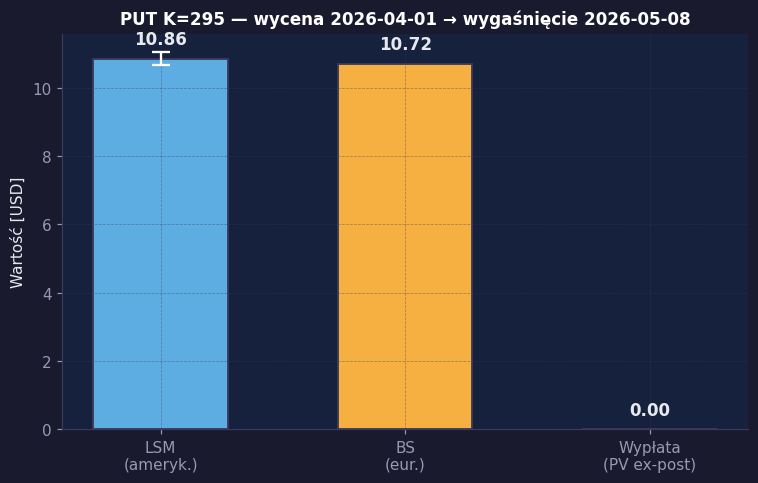

In [30]:
# Ostatni scenariusz — rozbicie na składowe
przyklad = wyniki[wyniki["typ"] == "PUT"].iloc[-1]

print("=" * 70)
print("PRZYKŁAD POJEDYNCZEJ WYCENY HISTORYCZNEJ")
print("=" * 70)
print(f"Data wyceny:         {przyklad['data_wyceny']}")
print(f"Data wygaśnięcia:    {przyklad['data_wygasniecia']}")
print(f"Czas do wygaśnięcia: {przyklad['T_lat']:.4f} lat ({przyklad['T_lat']*365:.0f} dni)")
print(f"\nParametry ex-ante (tylko dane do {przyklad['data_wyceny']}):")
print(f"  S₀ = {przyklad['S0']:.2f} USD")
print(f"  σ  = {przyklad['sigma']:.2%}  (252 sesje kończące się w dniu wyceny)")
print(f"  r  = {przyklad['r']:.2%}  (^IRX w dniu wyceny)")
print(f"  K  = {przyklad['K']:.0f} USD  (ATM)")
print(f"\nWynik ex-post (wygaśnięcie {przyklad['data_wygasniecia']}):")
print(f"  S_T = {przyklad['S_T']:.2f} USD")
print(f"  Wypłata intrinsic = {przyklad['wypłata_rzeczywista']:.4f} USD")
print(f"  Wypłata PV        = {przyklad['wypłata_zdyskontowana']:.4f} USD")
print(f"\nWyceny ex-ante:")
print(f"  LSM (amerykańska) = {przyklad['lsm']:.4f} ± {1.96*przyklad['lsm_se']:.4f}")
print(f"  BS  (europejska)  = {przyklad['bs']:.4f}")
print(f"  Premia ameryk.    = {przyklad['premia_amerykanska']:.4f}")
print(f"\nBłąd vs realizacja:")
print(f"  LSM − PV = {przyklad['blad_lsm']:+.4f} USD")
print(f"  BS  − PV = {przyklad['blad_bs']:+.4f} USD")

# Wykres porównawczy dla tego scenariusza
labels = ["LSM\n(ameryk.)", "BS\n(eur.)", "Wypłata\n(PV ex-post)"]
values = [przyklad["lsm"], przyklad["bs"], przyklad["wypłata_zdyskontowana"]]
bar_colors = [COLORS["lsm"], COLORS["bs"], COLORS["realized"]]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, values, color=bar_colors, edgecolor=DARK_GRID, linewidth=1.2, width=0.55)
ax.errorbar(0, przyklad["lsm"], yerr=1.96 * przyklad["lsm_se"],
            fmt="none", ecolor="#ffffff", capsize=6, capthick=1.5, lw=1.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.2f}", ha="center", va="bottom", color=DARK_TEXT, fontsize=11, fontweight="bold")
ax.set_ylabel("Wartość [USD]")
ax.set_title(
    f"PUT K={przyklad['K']:.0f} — wycena {przyklad['data_wyceny']} → wygaśnięcie {przyklad['data_wygasniecia']}",
    fontsize=11,
)
_style_ax(ax)
plt.tight_layout()
plt.show()

## Podsumowanie

| Element | Opis |
|---------|------|
| **Backtest wielospółkowy** | GOOG, AAPL, MSFT, NVDA, PLTR, JPM, RACE, GS, AMZN, GE |
| **Średnia LSM − BS** | Premia za wczesne wykonanie — agregacja per spółka, typ i globalnie |
| **Brak look-ahead** | $\sigma$, $r$, $S_0$ liczone wyłącznie z danych $\leq t_0$ |
| **LSM** | Amerykańska opcja — optymalne wczesne wykonanie |
| **Black–Scholes** | Europejska opcja — dolne ograniczenie |

**Interpretacja LSM − BS:**
- **PUT** — zwykle dodatnia premia (wczesne wykonanie opłacalne).
- **CALL** (bez dywidendy) — teoretycznie ≈ 0; odchylenia wynikają z błędu MC.
- **Średnia globalna** — zbiorcza miara różnicy amerykańskiej vs europejskiej wyceny.